In [1]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

In [2]:
import sys

sys.path.append('../scripts')

In [78]:
import numpy as np
import scanpy as sc
import anndata as ad
import pandas as pd
import os
import seaborn as sns

from utils import set_seed

import mintflow

# Get dataset

In [4]:
set_seed(0)
batch_size = 4096

In [5]:
adata = sc.read(
    f"/data2/a330d/datasets/cosmx/crc_wt_cosmx/crc_202.h5ad",
    backup_url=f"https://zenodo.org/records/15574384/files/242.h5ad?download=1"
)
# adata.obsm = {} # NOTE: only some strange PCA embeddings are stored in obsm, which we don't need
adata.obs_names_make_unique()

label_to_coarse = {
    "epi1": "Epithelial",
    "epi2": "Epithelial",
    "epi3": "Epithelial",
    "epi4": "Epithelial",
    
    "fib1": "Fibroblast",
    "fib2": "Fibroblast",
    
    "EC": "Endothelial",
    "SMC": "Smooth_muscle",
    
    "BC": "B_cell",
    "PC_IgA": "Plasma_cell",
    "PC_IgG": "Plasma_cell",
    "PC_IgM": "Plasma_cell",
    
    "TC": "T_cell",
    
    "mye1": "Myeloid",
    "mye2": "Myeloid",
    
    "mast": "Mast_cell",
}

adata.obs["coarse_type"] = adata.obs['ist'].map(label_to_coarse)
labels_key = 'coarse_type'
domains_key = 'typ'
batch_key = 'sid'
adata = adata[~adata.obs[domains_key].isna()] # NOTE: Interesting to annotate?
adata = adata[~adata.obs[labels_key].isna()]

sc.pp.filter_cells(adata, min_counts=3)
sc.pp.filter_genes(adata, min_counts=3)

/data/a330d/miniforge3/envs/mintflow/lib/python3.11/site-packages/scanpy/preprocessing/_simple.py:174: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs["n_counts"] = number


In [6]:
adata.obs[labels_key] = adata.obs[labels_key].astype('category')
adata.obsm['spatial'] = adata.obs[['CenterX_global_px', 'CenterY_global_px']].values
adata.layers['counts'] = adata.X.copy()
sc.pp.highly_variable_genes(adata, layer='counts', flavor='seurat_v3', n_top_genes=2000, subset=True)

In [7]:
from cellina._spatial_utils import spatial_neighbors

n_neighbors = 50
spatial_neighbors(adata, bandwidth=np.inf, max_neighbours=n_neighbors, standardize=False)

In [8]:
adata.obs['neighbor'] = adata.obsp['spatial_connectivities'][:,0].toarray().astype(np.float32)

In [9]:
from scipy.sparse import csr_matrix

sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
adata.obsm['spatial_x'] = adata.obsp['spatial_connectivities'] @ adata.X / n_neighbors
# float32
adata.obsm['spatial_x'] = csr_matrix(adata.obsm['spatial_x']).astype(np.float32)

## Data splits

In [10]:
split = "ood"

# Get holdout indices
if split == "random":
    fraction = 0.1
    n_cells = adata.n_obs
    n_holdout = int(n_cells * fraction)

    # Randomly choose cells
    test_idx = np.random.choice(n_cells, n_holdout, replace=False)

elif split == "ood":
    # OOD: Non-ref, non-epithelial
    #is_tumor_region  = adata.obs["typ"].str.contains("CRC|TVA", regex=True)
    is_tumor_region  = adata.obs["typ"].str.contains("CRC", regex=True)
    is_non_epi = adata.obs["coarse_type"] != "Epithelial"

    # Combine for test set
    test_mask = (is_tumor_region) & (is_non_epi)
    test_idx = np.where(test_mask)[0]
else:
    raise ValueError(f"Unknown split: {split}")

# Get train/val indices
all_idx = np.arange(adata.n_obs)
trainval_idx = np.setdiff1d(all_idx, test_idx)

In [11]:
# Set 'is_holdout' to False by default, then True for selected cells
adata.obs['is_holdout'] = False
adata.obs.iloc[test_idx, adata.obs.columns.get_loc('is_holdout')] = True

In [12]:
from sklearn.model_selection import train_test_split

validation_size = 0.1
train_idx, val_idx = train_test_split(
    trainval_idx,
    test_size=validation_size,
    random_state=0,
    shuffle=True,
)

In [49]:
adata.X = adata.layers['counts'].copy() # NOTE: use raw counts for training

In [50]:
adata.write_h5ad(f"/data2/a330d/datasets/cosmx/crc_wt_cosmx/crc_202_mintflow.h5ad")

# Mintflow

In [30]:
num_epochs = 20
batch_size = 4096

labels_key = 'coarse_type'
patient_id = 'sid'
n_neighbors = 5
x_pos = 'CenterX_global_px'
y_pos = 'CenterY_global_px'
use_wandb = False
n_particles = 10    # Number of predictions per cell for mintflow

## Create mintflow adatas

In [ ]:
path_anndata = '/data2/a330d/datasets/cosmx/crc_wt_cosmx/crc_202_mintflow.h5ad'
adata = sc.read_h5ad(path_anndata)

In [ ]:
# -------------------------
# Define training mask
# -------------------------

train_mask = (
    (adata.obs["typ"].str.contains("REF|TVA", regex=True)) |
    (
        (adata.obs["typ"].str.contains("CRC", regex=True)) &
        (adata.obs["coarse_type"] == "Epithelial")
    )
)

adata_train = adata[train_mask].copy()
adata_eval = adata[~train_mask].copy()

print("Training cells:", adata_train.n_obs)
print("Held-out CRC non-epithelial:", adata_eval.n_obs)

Training cells: 384099
Held-out CRC non-epithelial: 36595


In [ ]:
import anndata as ad

max_cells = 50000
subsets = []

for niche in adata_train.obs["typ"].unique():
    ad_n = adata_train[adata_train.obs["typ"] == niche].copy()
    
    if ad_n.n_obs > max_cells:
        idx = np.random.choice(ad_n.obs_names, max_cells, replace=False)
        ad_n = ad_n[idx].copy()
    
    subsets.append(ad_n)

adata_train = ad.concat(subsets, axis=0)

In [ ]:
adata_train.X = adata_train.X.tocsr()
adata_eval.X  = adata_eval.X.tocsr()

In [5]:
outdir = "/data2/a330d/datasets/mintflow_single_section"
os.makedirs(outdir, exist_ok=True)

adata_train.obs["sliceID"] = "slide1"
adata_train.obs["batchID"] = "slide1"

adata_train.obs["sliceID"] = adata_train.obs["sliceID"].astype("category")
adata_train.obs["batchID"] = adata_train.obs["batchID"].astype("category")

train_file = os.path.join(outdir, "slide1_train.h5ad")
adata_train.write_h5ad(train_file)


In [ ]:
adata_eval.obs["sliceID"] = "slide1_eval"
adata_eval.obs["batchID"] = "slide1_eval"

adata_eval.obs["sliceID"] = adata_eval.obs["sliceID"].astype("category")
adata_eval.obs["batchID"] = adata_eval.obs["batchID"].astype("category")

eval_file = os.path.join(outdir, "crc_other_eval.h5ad")
adata_eval.write_h5ad(eval_file)

## Training

In [17]:
config_data_train, config_data_evaluation, config_model, config_training = \
    mintflow.get_default_configurations(
        num_tissue_sections_training=1,
        num_tissue_sections_evaluation=1
    )

In [4]:
outdir = "/data2/a330d/datasets/mintflow_single_section"
os.makedirs(outdir, exist_ok=True)
train_file = os.path.join(outdir, "slide1_train.h5ad")
eval_file = os.path.join(outdir, "crc_other_eval.h5ad")

In [19]:
# configure tissue section 1 =========
config_data_train['list_tissue']['anndata1']['file'] = train_file
#   the absolute path to anndata object of tissue section 1 on disk.

config_data_train['list_tissue']['anndata1']['obskey_cell_type'] = labels_key
#   meaning that for the 1st tissue section, cell type labels are provided in `broad_celltypes` column of `adata.obs`.

config_data_train['list_tissue']['anndata1']['obskey_sliceid_to_checkUnique'] = patient_id
#   meaning that for the 1st tissue section, tissue section ID (i.e. slice ID) is provided in `sid` column of `adata.obs`

config_data_train['list_tissue']['anndata1']['obskey_x'] = x_pos
#   meaning that for the 1st tissue section, spatial x coordinates are provided in `CenterX_global_px` column of `adata.obs`

config_data_train['list_tissue']['anndata1']['obskey_y'] = y_pos
#   meaning that for the 1st tissue section, spatial y coordinates are provided in `CenterY_global_px` column of `adata.obs`

config_data_train['list_tissue']['anndata1']['obskey_biological_batch_key'] = patient_id
#   meaning that for the 1st tissue section, batch identifier is provided in `info_id` column of `adata.obs`

config_data_train['list_tissue']['anndata1']['config_dataloader_train']['width_window'] = batch_size
#   For tissue section one, the crop size of the customized dataloader desribed in Supplementary Fig. 16 of the paper.
#   The larger this number, the larger the tissue crops, and the bigger the subset of cells in each training iteration.
#      This implies that more GPU memory would be required during training.
#   In this notebook after calling `mintflow.setup_data` in Sec 4 the crop(s) are shown on tissue, 
#      with some information on image title which can help you tune this parameter.
#   In the manuscript we used `width_window` values between 300 and 800 depending on dataset.

config_data_train['list_tissue']['anndata1']['config_neighbourhood_graph'] = {
    'n_neighs': n_neighbors,
    'set_diag': 'False',
    'delaunay': 'False',
}
#   The parameters for creating the neighbourhood graph for training tissue section 1

In [20]:
config_data_evaluation['list_tissue']['anndata1']['file'] = train_file
config_data_evaluation['list_tissue']['anndata1']['obskey_cell_type'] = labels_key
config_data_evaluation['list_tissue']['anndata1']['obskey_sliceid_to_checkUnique'] = patient_id
config_data_evaluation['list_tissue']['anndata1']['obskey_x'] = x_pos
config_data_evaluation['list_tissue']['anndata1']['obskey_y'] = y_pos
config_data_evaluation['list_tissue']['anndata1']['obskey_biological_batch_key'] = patient_id
config_data_evaluation['list_tissue']['anndata1']['config_dataloader_test']['width_window'] = batch_size
config_data_evaluation['list_tissue']['anndata1']['config_neighbourhood_graph'] = {
    'n_neighs': n_neighbors,
    'set_diag': 'False',
    'delaunay': 'False',
}

In [21]:
config_data_train = mintflow.verify_and_postprocess_config_data_train(config_data_train) 

In [22]:
config_data_evaluation = mintflow.verify_and_postprocess_config_data_evaluation(config_data_evaluation)

In [23]:
config_model = mintflow.verify_and_postprocess_config_model(
    config_model,
    num_tissue_sections=1
)

 There is only one training tissue section --> the batch mixing coefficients `config_model['coef_xbarint2notbatchID_loss']` and `config_model['coef_xbarspl2notbatchID_loss']` were automatically set to 0.


In [ ]:
config_training['num_training_epochs'] = num_epochs
# number of training epochs, i.e. the number of times the model sees the dataset during training.

config_training['flag_enable_wandb'] = use_wandb

In [25]:
config_training = mintflow.verify_and_postprocess_config_training(config_training)

checking if /data2/a330d/datasets/mintflow_single_section/slide1_train.h5ad and /data2/a330d/datasets/mintflow_single_section/slide1_train.h5ad share the same gene panel
    >>> also checked that anndata.X contains count data.
checking if /data2/a330d/datasets/mintflow_single_section/slide1_train.h5ad and /data2/a330d/datasets/mintflow_single_section/slide1_train.h5ad share the same gene panel
    >>> also checked that anndata.X contains count data.


Device is set to cuda:0.


INFO     Creating graph using `generic` coordinates and `None` transform and `1` libraries.                        


/data/a330d/miniforge3/envs/mintflow_env/lib/python3.11/site-packages/torch_geometric/sampler/neighbor_sampler.py:61: UserWarning: Using 'NeighborSampler' without a 'pyg-lib' installation is deprecated and will be removed soon. Please install 'pyg-lib' for accelerated neighborhood sampling
  warnings.warn(f"Using '{self.__class__.__name__}' without a "
/data/a330d/miniforge3/envs/mintflow_env/lib/python3.11/site-packages/mintflow/utils_multislice.py:271: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  x=torch.sparse_coo_tensor(


 Double-checked floating point conversion on adata.X.
Using the custom sampler for pygloader.


created list_slice for training.
Tissue {242} --> 144002 cells



INFO     Creating graph using `generic` coordinates and `None` transform and `1` libraries.                        


/data/a330d/miniforge3/envs/mintflow_env/lib/python3.11/site-packages/torch_geometric/sampler/neighbor_sampler.py:61: UserWarning: Using 'NeighborSampler' without a 'pyg-lib' installation is deprecated and will be removed soon. Please install 'pyg-lib' for accelerated neighborhood sampling
  warnings.warn(f"Using '{self.__class__.__name__}' without a "


 Double-checked floating point conversion on adata.X.
Using the custom sampler for pygloader.


created list_slice for evaluation.
Tissue {242} --> 144002 cells





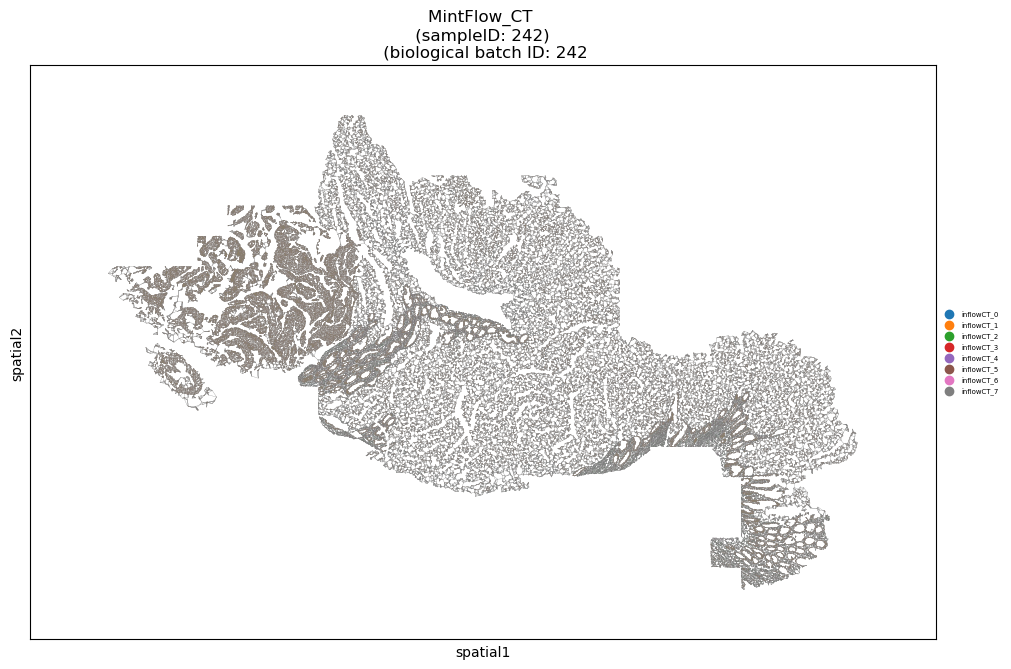

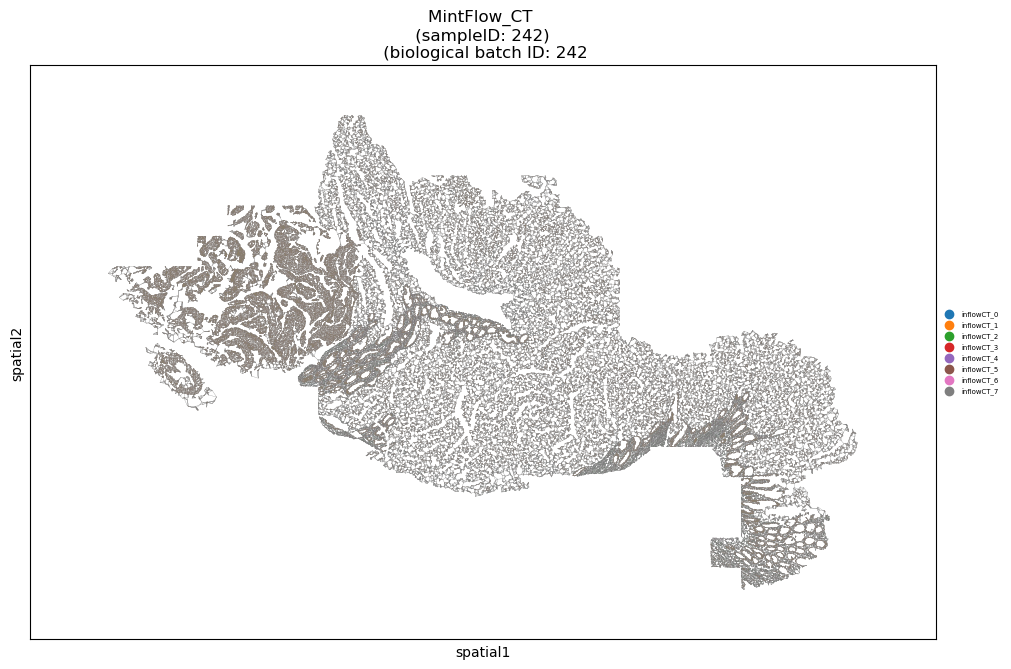





The provided cell types are aggregated/mapped to mintflow cell types as follow:
{'Endothelial': 'inflowCT_0',
 'Epithelial': 'inflowCT_1',
 'Fibroblast': 'inflowCT_2',
 'Mast_cell': 'inflowCT_3',
 'Myeloid': 'inflowCT_4',
 'Plasma_cell': 'inflowCT_5',
 'Smooth_muscle': 'inflowCT_6',
 'T_cell': 'inflowCT_7'}







The provided biological batch IDs are aggregated/mapped to mintflow batch IDs as follows
{242: 'inflow_BatchID_0'}



One-hot encoded batch ID for each sample (tissue):
     sample 242 --> batch ID {0}
Customised neighbourloader sampler: computing some initial stats (max number of central nodes, etc) for each tissue.
Tissue # 1


  0%|          | 0/144002 [00:00<?, ?it/s]

  0%|          | 0/144002 [00:00<?, ?it/s]

    width_window=4096 --> [maxnum_centralnodes:2416.0,    worse-case batchsize:14506]


  0%|          | 0/144002 [00:00<?, ?it/s]

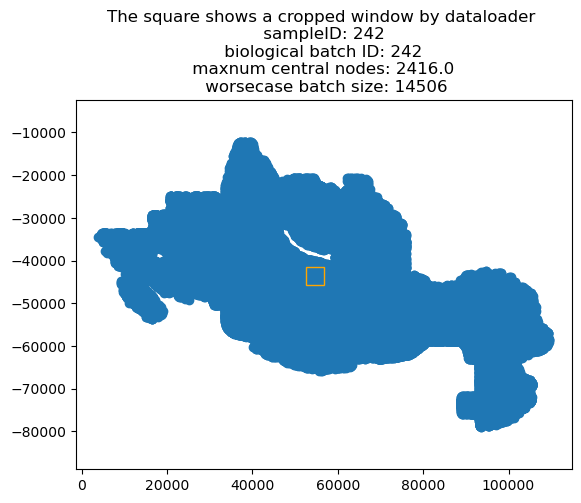

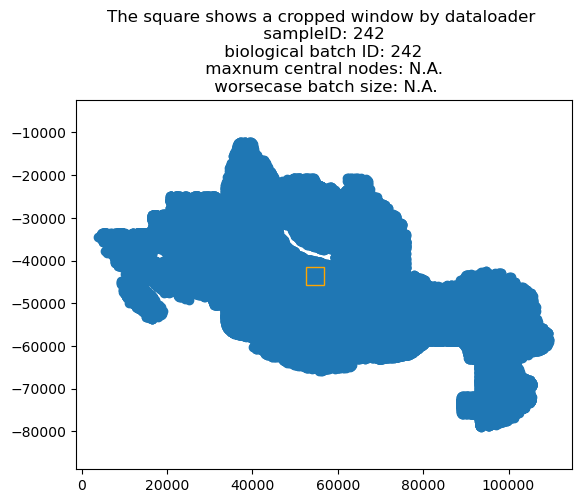

In [26]:
dict_all4_configs = {
    "config_data_train": config_data_train,
    "config_data_evaluation": config_data_evaluation,
    "config_model": config_model,
    "config_training": config_training,
}

data_mintflow = mintflow.setup_data(dict_all4_configs=dict_all4_configs)

In [27]:
model = mintflow.setup_model(
    dict_all4_configs=dict_all4_configs,
    data_mintflow=data_mintflow
)



Device is set to cuda:0.




dict_pname_to_scaleandunweighted is set to:
{'sin': [0.1, True],
 'sout': [1.0, True],
 'x': [None, None],
 'xbar_int': [0.1, True],
 'xbar_spl': [0.1, True],
 'z': [1.0, True]}



{'CT': '1.ArchInsertionPoint', 'NCC': '3.ArchInsertionPoint'}

dict_qname_to_scaleandunweighted is set to: 
{'impanddisentgl_int': {'flag_unweighted': True, 'scale': 0.1},
 'impanddisentgl_spl': {'flag_unweighted': True, 'scale': 0.0},
 'sin': {'flag_unweighted': True, 'scale': 1.0},
 'sout': {'flag_unweighted': True, 'scale': 0.0},
 'varphi_enc_int': {'flag_unweighted': True, 'scale': 0.0},
 'varphi_enc_spl': {'flag_unweighted': True, 'scale': 0.0},
 'z': {'flag_unweighted': True, 'scale': 1.0}}


The way CTs/NCCs are fed to the 3rd encoder:
{'sin': [False, True], 'sout': [True, False], 'z': [True, False]}
MintFlow module was created on cuda:0.


In [28]:
trainer = mintflow.Trainer(
    dict_all4_configs=dict_all4_configs,
    model=model,
    data_mintflow=data_mintflow
)

In [29]:
path_output_files = "/data2/a330d/datasets/mintflow_single_section/NonGit/Outputs_TutorialNotebook1"
os.makedirs(path_output_files, exist_ok=True)

In [32]:
for epoch in range(config_training["num_training_epochs"]):
    trainer.train_one_epoch()

    mintflow.dump_checkpoint(
        model=model,
        data_mintflow=data_mintflow,
        dict_all4_configs=dict_all4_configs,
        path_dump=os.path.join(path_output_files, "checkpoint_epoch_{}.pt".format(epoch)),
    )    

     Getting different embeddings to update the dual functions separately.


Tissue 0:   0%|          | 0/223 [00:00<?, ?it/s]

Training the dual functions separately.:   0%|          | 0/200 [00:00<?, ?it/s]

MintFlow training epoch:   0%|          | 0/227 [00:00<?, ?it/s]

/data/a330d/miniforge3/envs/mintflow_env/lib/python3.11/site-packages/mintflow/generativemodel.py:869: UserWarning: The value argument must be within the support of the distribution
  ).log_prob(dict_qsamples['x_int'][:batch.batch_size])  # [b, num_genes]
/data/a330d/miniforge3/envs/mintflow_env/lib/python3.11/site-packages/mintflow/generativemodel.py:893: UserWarning: The value argument must be within the support of the distribution
  ).log_prob(dict_qsamples['x_spl'][:batch.batch_size])  # [b, num_genes]


...

MintFlow training epoch:   0%|          | 0/227 [00:00<?, ?it/s]

     Getting different embeddings to update the dual functions separately.


Tissue 0:   0%|          | 0/223 [00:00<?, ?it/s]

Training the dual functions separately.:   0%|          | 0/200 [00:00<?, ?it/s]

MintFlow training epoch:   0%|          | 0/227 [00:00<?, ?it/s]

# Eval via in-silico GEX prediction

In [31]:
import scanpy as sc

adata_eval = sc.read_h5ad(eval_file)

In [35]:
import torch

# Your checkpoint with model and data
trained_checkpoint_path = os.path.join(path_output_files, f"checkpoint_epoch_{num_epochs-1}.pt")

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

checkpoint_mintflow = torch.load(
    trained_checkpoint_path,
    map_location='cpu',
    weights_only=False
)
checkpoint_mintflow['model'].to(device)
print("Loaded the checkpoint.")

Loaded the checkpoint.


In [37]:
result_generation = mintflow.generate_insilico_ST_data(
    adata=adata_eval,
    obskey_celltype='coarse_type',
    obspkey_neighbourhood_graph='spatial_connectivities',
    device=device,
    batch_index_trainingdata=0,
    num_generated_realisations=n_particles,
    model=checkpoint_mintflow['model'],
    data_mintflow=checkpoint_mintflow['data_mintflow'],
    dict_all4_configs=checkpoint_mintflow['dict_all4_configs'],
    estimate_spatial_sizefactors_on_sections=[0]
)

Evaluating on tissue section: 0:   0%|          | 0/223 [00:00<?, ?it/s]

/data/a330d/miniforge3/envs/mintflow_env/lib/python3.11/site-packages/torch_geometric/sampler/neighbor_sampler.py:61: UserWarning: Using 'NeighborSampler' without a 'pyg-lib' installation is deprecated and will be removed soon. Please install 'pyg-lib' for accelerated neighborhood sampling
  warnings.warn(f"Using '{self.__class__.__name__}' without a "


Generating the realisations of the expression data (i.e. generative samples) for the provided in silico tissue…

/data/a330d/miniforge3/envs/mintflow_env/lib/python3.11/site-packages/mintflow/generativemodel.py:546: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(edge_index),
/data/a330d/miniforge3/envs/mintflow_env/lib/python3.11/site-packages/torch_geometric/sampler/neighbor_sampler.py:61: UserWarning: Using 'NeighborSampler' without a 'pyg-lib' installation is deprecated and will be removed soon. Please install 'pyg-lib' for accelerated neighborhood sampling
  warnings.warn(f"Using '{self.__class__.__name__}' without a "


In [ ]:
for k, v in result_generation['list_generated_realisations_ie_expressions'][0].items():
    print(k, v.shape)

In [43]:
adata_eval.obsm['mintflow_recon_x'] = np.stack(
    [realisation['MintFlow_Generated_Xint'] + realisation['MintFLow_Generated_Xmic'] for realisation in result_generation['list_generated_realisations_ie_expressions']]
).mean(0)

<Axes: ylabel='Count'>

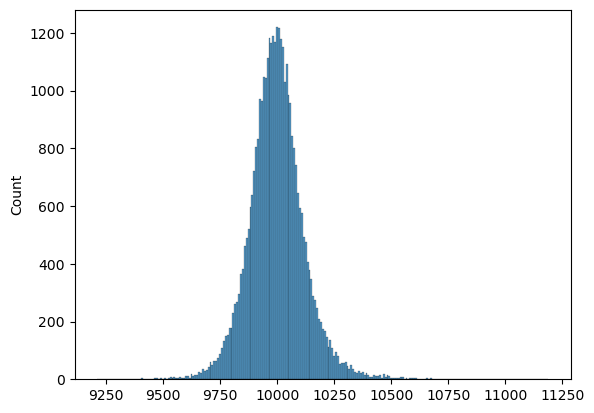

In [ ]:

sns.histplot(adata_eval.obsm['mintflow_recon_x'].sum(axis=1))

In [49]:
x_hat = adata_eval.obsm['mintflow_recon_x']

In [46]:
for k, v in result_generation['list_generated_realisations_ie_expressions'][0].items():
    print(k, v.shape)

MintFlow_Generated_Z (36595, 100)
MintFLow_Generated_S_out (36595, 100)
MintFLow_Generated_S_in (36595, 100)
MintFlow_Generated_Xbar_int (36595, 100)
MintFlow_Generated_Xbar_mic (36595, 100)
MintFlow_Generated_Xint (36595, 2000)
MintFLow_Generated_Xmic (36595, 2000)
MintFlow_Generated_Xint_softmax_output (36595, 2000)
MintFlow_Generated_Xmic_softmax_output (36595, 2000)
MintFlow_Cond_int (36595, 8)
MintFlow_Cond_mic (36595, 8)


In [52]:
np.save("/data2/a330d/datasets/mintflow_xhat_202", x_hat)

# Plots

In [ ]:
# Load training adata and set recon_x to 0 (recon_x for train data is not used for eval)
adata_train = sc.read_h5ad(train_file)
adata_train.obsm['recon_x'] = np.zeros((adata_train.n_obs, adata_train.n_vars))

In [ ]:
# Set adata_train.obs['group'] to 'target' for CRC cells - only Epi should be affected in this adata
adata_train.obs['group'] = 'control'
mask = adata_train.obs['typ'].str.contains("CRC", regex=True)
adata_train.obs.loc[mask, 'group'] = 'target'

In [ ]:
# Read holdout adata and load mintflow recon into obsm
adata_eval = sc.read_h5ad(eval_file)
adata_eval.obsm['recon_x'] = np.load("/data2/a330d/datasets/mintflow_xhat_202.npy")

In [ ]:
# Create counterfactual - just copy eval adata in this case. 
# We will use adata_cf.obsm['recon_x'] and adata_eval.layers['counts'] as predicted and gt respectively
adata_cf = adata_eval.copy()

In [ ]:
# Set groups for gt target and predicted target adatas
adata_eval.obs['group'] = 'target'
adata_cf.obs['group'] = 'counterfactual'

In [48]:
adata_merged = ad.concat([adata_train, adata_eval, adata_cf], axis=0)

/data/a330d/miniforge3/envs/mintflow/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [ ]:
# Normalize each cell to total counts of 1e4 to match Mintflow
sc.pp.normalize_total(adata_merged, target_sum=1e4)

# Store normalized counts in a layer
adata_merged.layers["counts"] = adata_merged.X.copy()

In [ ]:
# Create a dict where adatas for cell types are separate
mintflow_dict = {}

for n, g in adata_merged.obs.groupby('coarse_type'):
    if n == 'Epithelial':
        continue
    mintflow_dict[n] = adata_merged[adata_merged.obs['coarse_type'] == n].copy()

/tmp/ipykernel_2277387/2594303492.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for n, g in adata_merged.obs.groupby('coarse_type'):
/data/a330d/miniforge3/envs/mintflow/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/data/a330d/miniforge3/envs/mintflow/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/data/a330d/miniforge3/envs/mintflow/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils

<Axes: ylabel='Count'>

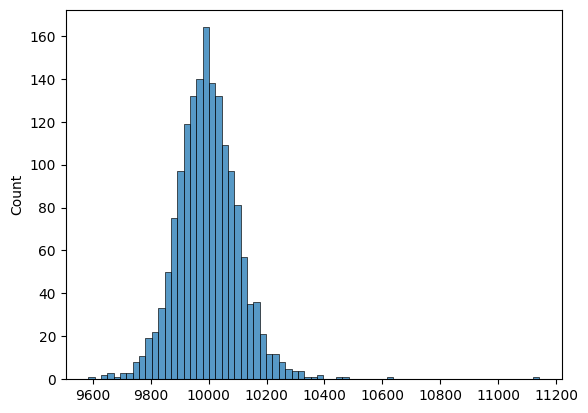

In [115]:
a = mintflow_dict['Endothelial'][mintflow_dict['Endothelial'].obs['group']=='counterfactual']
sns.histplot(a.obsm['recon_x'].sum(axis=1))

In [110]:
from counterfactual_analysis import get_de_correlations

In [ ]:
k = 50
plot = True
use_recon = False
normalize_counts = False # Counts are already normlized to sum to 1e4

  0%|          | 0/7 [00:00<?, ?it/s]

100%|██████████| 7/7 [00:03<00:00,  1.98it/s]


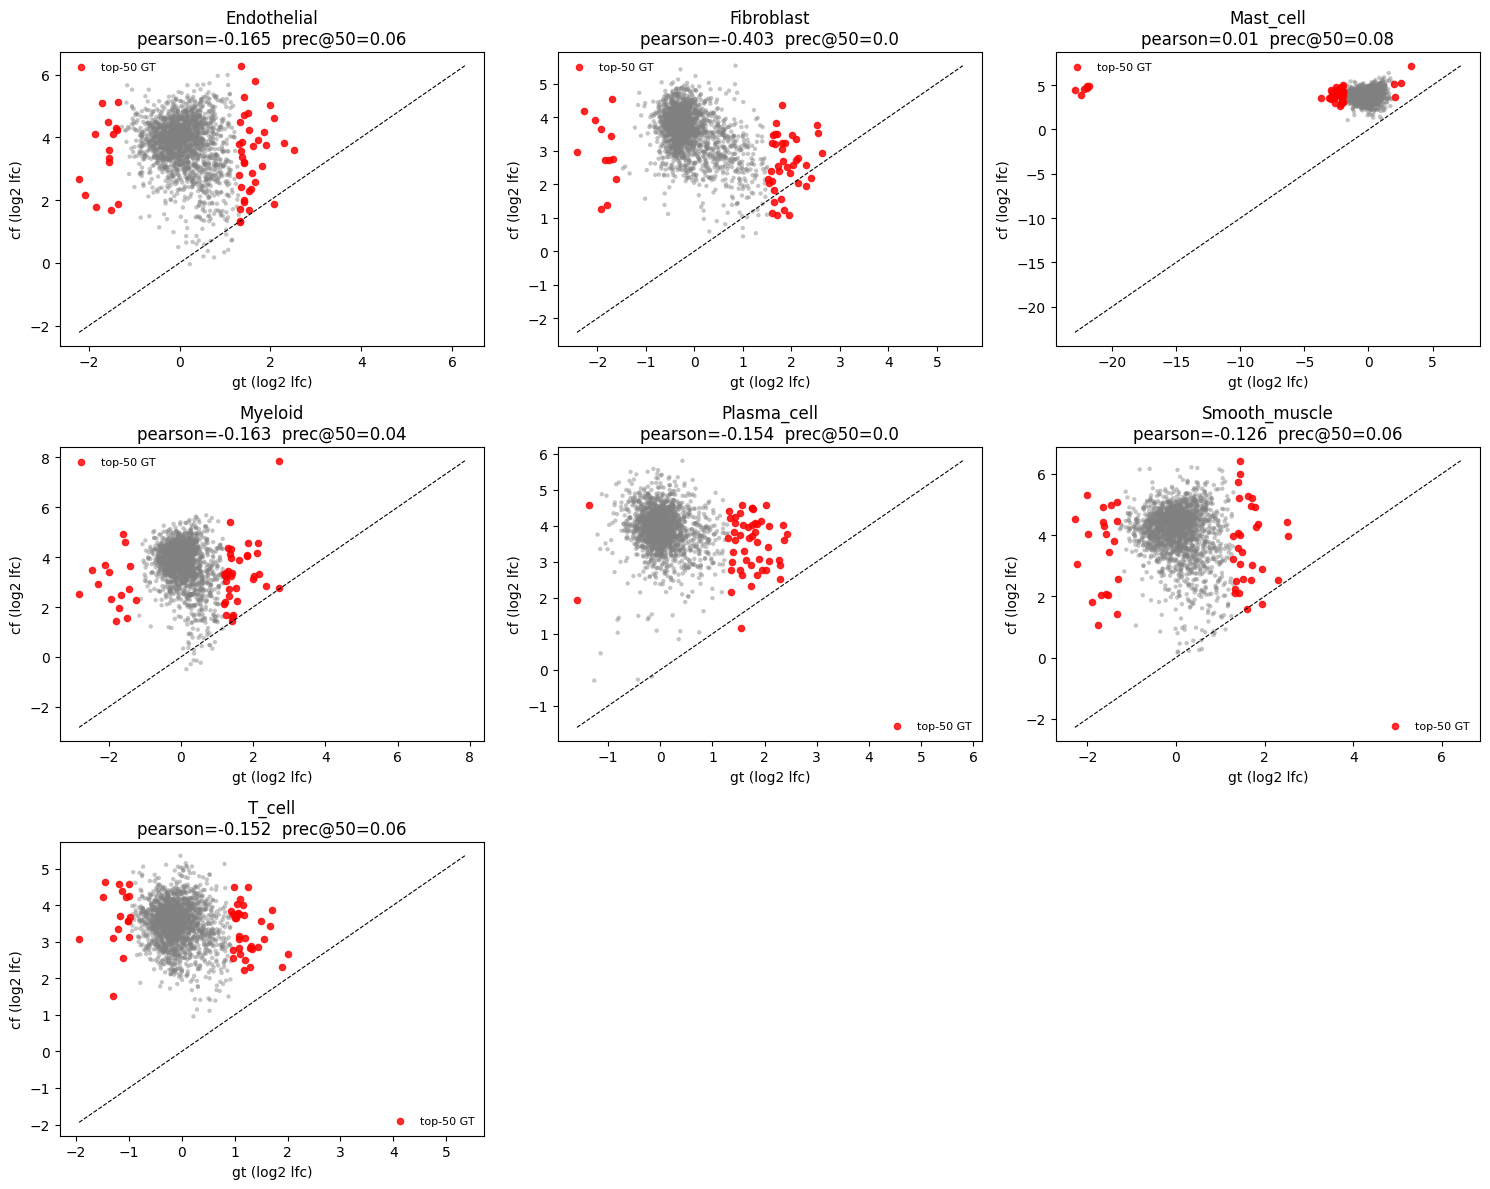

In [112]:
mintflow_lfc, _ = get_de_correlations(mintflow_dict, k=k, plot=plot, use_recon=use_recon, normalize_counts=normalize_counts)

In [113]:
df_base_path = '../results'

In [114]:
results_df = pd.DataFrame(mintflow_lfc)
summary_df = results_df.groupby("celltype")[["pearson", "spearman"]].mean().reset_index()

# save for later use
summary_df.to_csv(os.path.join(df_base_path, "mintflow_by_celltype_correlations.csv"), index=False)
summary_df

,celltype,pearson,spearman
0,Endothelial,-0.165394,-0.116202
1,Fibroblast,-0.403404,-0.309801
2,Mast_cell,0.010074,0.121696
3,Myeloid,-0.163495,-0.139248
4,Plasma_cell,-0.154283,-0.152754
5,Smooth_muscle,-0.126420,-0.073373
6,T_cell,-0.151972,-0.101700
